# NeuralMag vortex Ms fit

This notebook builds a MuMax-like cylindrical vortex, relaxes it with NeuralMag at two saturation magnetizations, projects the relaxed magnetization through the MBIR phase model, and fits `Msat` back from the phase image.

The active workflow is deliberately narrow:

1. define the cylinder, material, and two `Msat` cases;
2. generate relaxed reference states with fixed-time LLG;
3. use the 300 kA/m state as the initial guess and the 800 kA/m phase as the target;
4. run a differentiable NeuralMag BB/Cayley relaxation inside a scalar Adam fit for `Msat`.

The optional 3D cell at the end writes VTI files for PyVista inspection.


In [1]:
from __future__ import annotations

import os
import sys
import time
from pathlib import Path

# Set JAX process flags before importing JAX/Optax/NeuralMag.
os.environ["JAX_ENABLE_X64"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.4"

from jax import config as jax_config

jax_config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import unxt as u

cwd = Path.cwd().resolve()
repo_root = next((p for p in (cwd, *cwd.parents) if (p / "pyproject.toml").exists()), cwd)
for extra_path in (repo_root / "src", repo_root / "vendor/neuralmag"):
    if extra_path.exists() and str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from libertem_holo.base.mbir import MU_0, build_rdfc_kernel, forward_phase_from_density_and_magnetization

try:
    import neuralmag as nm
except ImportError as exc:
    raise ImportError(
        "This notebook requires NeuralMag. Use the repo notebook environment or install the vendored package."
    ) from exc

nm.config.dtype = "float64"
backend = getattr(getattr(nm, "config", None), "backend", None)
backend_name = getattr(backend, "name", backend)

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["image.origin"] = "lower"
np.set_printoptions(precision=5, suppress=True)

print(f"Repo root: {repo_root}")
print(f"NeuralMag backend: {backend_name}")


2026-04-29 15:32:35 NeuralMag:INFO [NeuralMag] Version 0.9.4
2026-04-29 15:32:35 NeuralMag:INFO [NeuralMag] Backend set to 'jax'.
2026-04-29 15:32:35 NeuralMag:INFO [NeuralMag] Set default dtype to 'float64'.


Repo root: /Users/landers/LiberTEM-holo
NeuralMag backend: jax


In [2]:
shape_xyz = (64, 64, 20)
cellsize_nm_xyz = np.array([5.0, 5.0, 1.0], dtype=np.float64)
diameter_nm = 320.0
thickness_nm = 20.0

material = {
    "A_J_per_m": 1.0e-11,
    "Di_J_per_m2": 0.0,
    "Ku_J_per_m3": 0.0,
    "alpha": 1.0,
}

msat_cases = {
    "800 kA/m": 800e3,
    "300 kA/m": 300e3,
}

target_case = "800 kA/m"
input_case = "300 kA/m"

# Keep these modest for notebook iteration; increase for final/reference data.
llg_max_steps = 2048
llg_dt_s = 2e-14
llg_target_steps = 5500
llg_time_s = llg_target_steps * llg_dt_s

demag_p = 3
bb_tol = 1e3
bb_max_iter = 5000
bb_tau_min = 1e-18
bb_tau_max = 1e-4

outer_steps = 750
outer_learning_rate = 0.25
msat_bounds = (2e5, 1.0e6)

print(f"Grid: {shape_xyz}, cell size xyz: {cellsize_nm_xyz} nm")
print(f"Cylinder: {diameter_nm:g} nm diameter, {thickness_nm:g} nm thick")
print("Material:", material)
print("Msat cases:", msat_cases)


Grid: (64, 64, 20), cell size xyz: [5. 5. 1.] nm
Cylinder: 320 nm diameter, 20 nm thick
Material: {'A_J_per_m': 1e-11, 'Di_J_per_m2': 0.0, 'Ku_J_per_m3': 0.0, 'alpha': 1.0}
Msat cases: {'800 kA/m': 800000.0, '300 kA/m': 300000.0}


In [3]:
def cell_centers_nm(shape_xyz, spacing_nm_xyz):
    axes = [
        (np.arange(n, dtype=np.float64) + 0.5) * spacing - (n * spacing / 2.0)
        for n, spacing in zip(shape_xyz, spacing_nm_xyz)
    ]
    return np.meshgrid(*axes, indexing="ij")


def cylinder_support_xyz(shape_xyz, spacing_nm_xyz, diameter_nm, thickness_nm):
    xx, yy, zz = cell_centers_nm(shape_xyz, spacing_nm_xyz)
    r = diameter_nm / 2.0
    support = (xx**2 + yy**2 <= r**2) & (np.abs(zz) <= thickness_nm / 2.0)
    return support.astype(np.float32)


def normalize_m(m_xyz, support_xyz, threshold=0.5):
    norm = np.linalg.norm(m_xyz, axis=-1, keepdims=True)
    unit = m_xyz / np.where(norm > 0.0, norm, 1.0)
    return np.where(support_xyz[..., None] > threshold, unit, 0.0).astype(np.float32)


def vortex_seed_xyz(support_xyz, spacing_nm_xyz, *, circulation=1, polarization=-1, core_radius_nm=18.0):
    xx, yy, _ = cell_centers_nm(support_xyz.shape, spacing_nm_xyz)
    phi = np.arctan2(yy, xx)
    radius = np.hypot(xx, yy)
    mz = polarization * np.exp(-((radius / core_radius_nm) ** 2))
    in_plane = np.sqrt(np.maximum(1.0 - mz**2, 0.0))

    m = np.zeros(support_xyz.shape + (3,), dtype=np.float32)
    m[..., 0] = -circulation * np.sin(phi) * in_plane
    m[..., 1] = circulation * np.cos(phi) * in_plane
    m[..., 2] = mz
    return normalize_m(m, support_xyz)


def constant_vector_cell_function(state, shape_xyz, vector_xyz):
    values = np.broadcast_to(np.asarray(vector_xyz, dtype=np.float64), tuple(shape_xyz) + (3,)).copy()
    return nm.VectorCellFunction(state, tensor=state.tensor(values, dtype=state.dtype))


def cell_m_to_node_function(state, m_cell_xyz, rho_cell_xyz):
    rho_cell = nm.CellFunction(state, tensor=state.tensor(rho_cell_xyz, dtype=state.dtype))
    m_cell = nm.VectorCellFunction(state, tensor=state.tensor(m_cell_xyz, dtype=state.dtype))
    rho_node = np.asarray(rho_cell.to_node().tensor)
    m_node = np.asarray(m_cell.to_node().tensor)

    norm = np.linalg.norm(m_node, axis=-1, keepdims=True)
    m_node = np.where(rho_node[..., None] > 0.5, m_node / np.where(norm > 0.0, norm, 1.0), 0.0)
    return nm.VectorFunction(state, tensor=state.tensor(m_node, dtype=state.dtype))


def build_vortex_state(rho_cell_xyz, m_cell_xyz, msat_a_per_m):
    mesh = nm.Mesh(tuple(rho_cell_xyz.shape), tuple((cellsize_nm_xyz * 1e-9).tolist()))
    state = nm.State(mesh)

    rho_min = float(getattr(state, "eps", 1e-12))
    state.rho = nm.CellFunction(state, tensor=state.tensor(np.clip(rho_cell_xyz, rho_min, 1.0), dtype=state.dtype))
    state.material.Ms = nm.CellFunction(state).fill(float(msat_a_per_m))
    state.material.A = nm.CellFunction(state).fill(material["A_J_per_m"])
    state.material.Di = nm.CellFunction(state).fill(material["Di_J_per_m2"])
    state.material.Di_axis = constant_vector_cell_function(state, rho_cell_xyz.shape, [0.0, 0.0, 1.0])
    state.material.Ku = nm.CellFunction(state).fill(material["Ku_J_per_m3"])
    state.material.Ku_axis = constant_vector_cell_function(state, rho_cell_xyz.shape, [0.0, 0.0, 1.0])
    state.material.alpha = state.tensor(float(material["alpha"]))
    state.m = cell_m_to_node_function(state, m_cell_xyz, rho_cell_xyz)
    state.t = state.tensor(0.0)

    nm.ExchangeField().register(state, "exchange")
    nm.DemagField(p=demag_p).register(state, "demag")
    nm.InterfaceDMIField().register(state, "idmi")
    nm.UniaxialAnisotropyField().register(state, "uaniso")
    nm.TotalField("exchange", "demag", "idmi", "uaniso").register(state)
    return state


def relax_fixed_time_llg(rho_cell_xyz, m_cell_xyz, msat_a_per_m):
    state = build_vortex_state(rho_cell_xyz, m_cell_xyz, msat_a_per_m)
    solver = nm.LLGSolver(state, max_steps=llg_max_steps)
    sol = solver.solve(state.tensor([0.0, llg_time_s]))
    state.m.tensor = sol.ys[-1]
    state.t = sol.ts[-1] * solver._scale_t
    return state


def xyz_to_zyx(values):
    axes = (2, 1, 0) if np.ndim(values) == 3 else (2, 1, 0, 3)
    return np.transpose(np.asarray(values), axes)


def phase_from_m_xyz(rho_xyz, m_xyz, msat_a_per_m, *, dtype=np.float32):
    rho_zyx = xyz_to_zyx(np.asarray(rho_xyz, dtype=dtype))
    m_zyx = xyz_to_zyx(np.asarray(m_xyz, dtype=dtype)) * (float(np.asarray(MU_0.value)) * float(msat_a_per_m))
    kernel = build_rdfc_kernel((rho_zyx.shape[1], rho_zyx.shape[2]), geometry="disc", dtype=dtype)
    return np.asarray(
        forward_phase_from_density_and_magnetization(
            rho=rho_zyx,
            magnetization_3d=m_zyx,
            pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
            projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
            axis="z",
            geometry="disc",
            rdfc_kernel=kernel,
        ),
        dtype=dtype,
    )


In [4]:
rho_cell = cylinder_support_xyz(shape_xyz, cellsize_nm_xyz, diameter_nm, thickness_nm)
m0_cell = vortex_seed_xyz(rho_cell, cellsize_nm_xyz, circulation=1, polarization=-1)

print(f"Support voxels: {int(rho_cell.sum())}")
print(f"Initial |m| on support: {np.linalg.norm(m0_cell[rho_cell > 0.5], axis=-1).mean():.5f}")

results = {}
for label, msat in msat_cases.items():
    print(f"Relaxing {label} with fixed-time LLG ...")
    started = time.perf_counter()
    state = relax_fixed_time_llg(rho_cell, m0_cell, msat)

    m_relaxed = normalize_m(np.asarray(state.m.to_cell().tensor), rho_cell)
    rho_relaxed = np.asarray(state.rho.tensor, dtype=np.float32)
    mean_m = m_relaxed[rho_relaxed > 0.5].mean(axis=0)
    phase_yx = phase_from_m_xyz(rho_relaxed, m_relaxed, msat)

    results[label] = {
        "Ms_A_per_m": float(msat),
        "rho": rho_relaxed,
        "m": m_relaxed,
        "m0": m0_cell,
        "phase_yx": phase_yx,
        "elapsed_s": time.perf_counter() - started,
        "mean_m": mean_m,
    }
    print(f"  {results[label]['elapsed_s']:.2f}s | mean m = {mean_m}")


2026-04-29 15:32:35 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-29 15:32:35 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-29 15:32:35 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)


Support voxels: 64560
Initial |m| on support: 1.00000
Relaxing 800 kA/m with fixed-time LLG ...


2026-04-29 15:32:36 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-29 15:32:36 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-29 15:32:36 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-29 15:32:40 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-29 15:32:40 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-29 15:32:40 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-29 15:32:40 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function
2026-04-29 15:32:54 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-29 15:32:54 NeuralMag:INFO [NeuralMag] Set default device to 'cud

  19.34s | mean m = [-0.       0.      -0.00225]
Relaxing 300 kA/m with fixed-time LLG ...


2026-04-29 15:32:56 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-29 15:32:56 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-29 15:32:56 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')
2026-04-29 15:32:56 NeuralMag:INFO [LLGSolverJAX] Initialize RHS function


  16.37s | mean m = [-0.       0.      -0.01852]


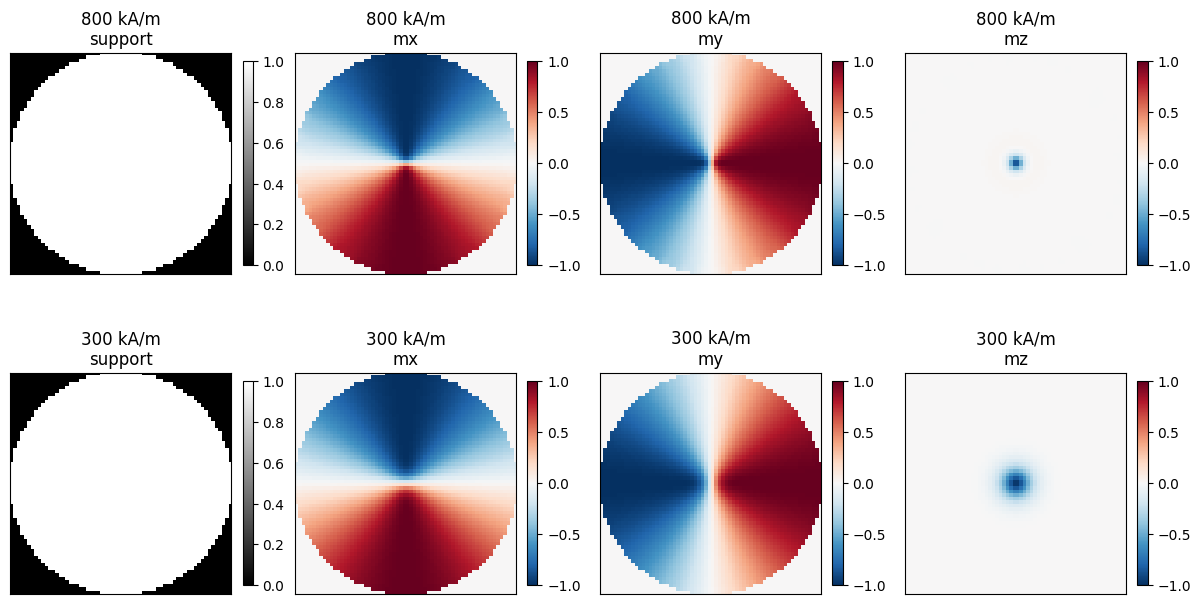

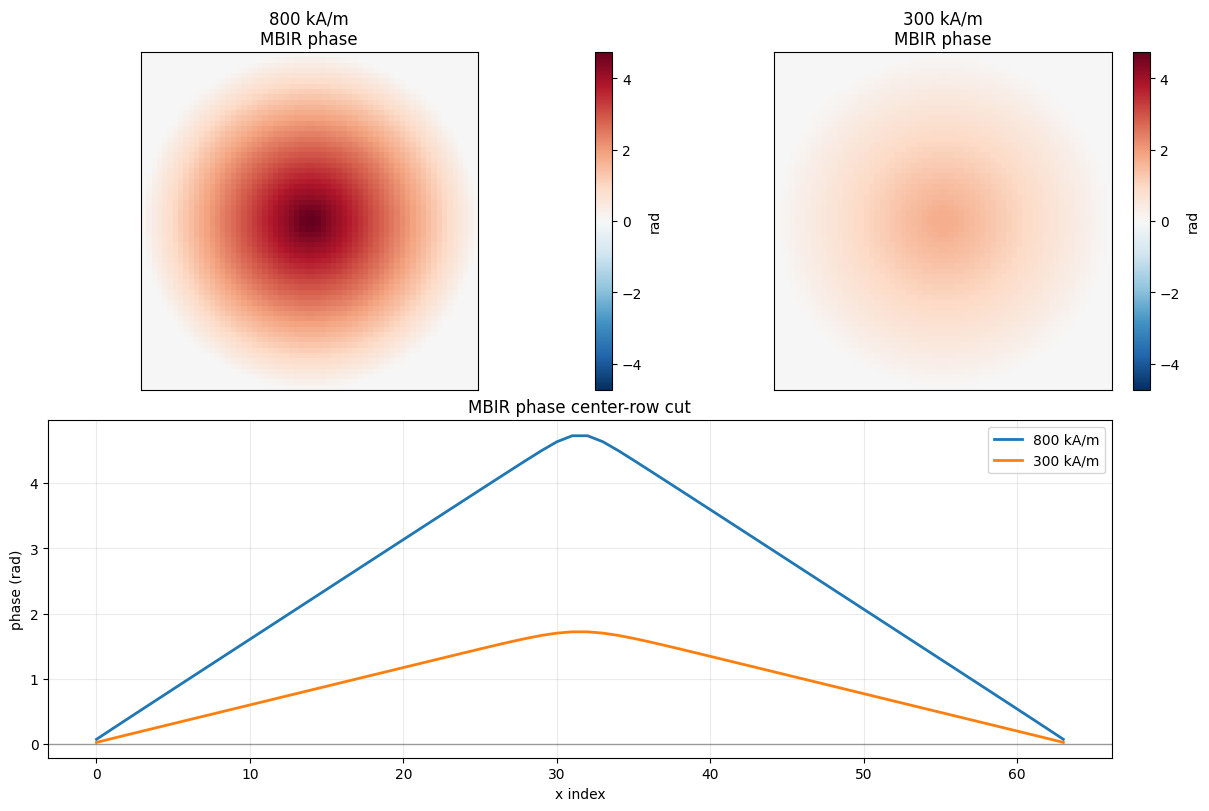

In [5]:
fig, axs = plt.subplots(len(results), 4, figsize=(12, 3.2 * len(results)), constrained_layout=True)
axs = np.atleast_2d(axs)

for row, (label, result) in enumerate(results.items()):
    rho = result["rho"]
    m = result["m"]
    mid = rho.shape[2] // 2
    panels = [
        (rho[:, :, mid].T, "support", "gray", 0.0, 1.0),
        (m[:, :, mid, 0].T, "mx", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 1].T, "my", "RdBu_r", -1.0, 1.0),
        (m[:, :, mid, 2].T, "mz", "RdBu_r", -1.0, 1.0),
    ]
    for col, (image, title, cmap, vmin, vmax) in enumerate(panels):
        im = axs[row, col].imshow(image, cmap=cmap, vmin=vmin, vmax=vmax)
        axs[row, col].set_title(f"{label}\n{title}")
        axs[row, col].set_xticks([])
        axs[row, col].set_yticks([])
        plt.colorbar(im, ax=axs[row, col], fraction=0.046)

plt.show()

phase_lim = max(max(abs(float(r["phase_yx"].min())), abs(float(r["phase_yx"].max()))) for r in results.values())
phase_lim = max(phase_lim, 1e-12)
fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = fig.add_gridspec(2, len(results))

for col, (label, result) in enumerate(results.items()):
    ax = fig.add_subplot(gs[0, col])
    im = ax.imshow(result["phase_yx"], cmap="RdBu_r", vmin=-phase_lim, vmax=phase_lim)
    ax.set_title(f"{label}\nMBIR phase")
    ax.set_xticks([])
    ax.set_yticks([])
    plt.colorbar(im, ax=ax, fraction=0.046, label="rad")

ax = fig.add_subplot(gs[1, :])
x_index = np.arange(shape_xyz[0])
for label, result in results.items():
    phase = result["phase_yx"]
    ax.plot(x_index, phase[phase.shape[0] // 2], linewidth=2.0, label=label)
ax.axhline(0.0, color="k", linewidth=1.0, alpha=0.35)
ax.set_title("MBIR phase center-row cut")
ax.set_xlabel("x index")
ax.set_ylabel("phase (rad)")
ax.grid(True, alpha=0.25)
ax.legend()
plt.show()


## Differentiable `Msat` fit

The fit uses NeuralMag's `EnergyMinimizer` as the inner physics solver. For each scalar `Msat` candidate, the notebook relaxes the input magnetization with BB/Cayley, projects the relaxed cell magnetization through the MBIR phase model, and compares the phase to the target. The gradient is a scalar forward-mode JVP through the relaxation and phase projection.


In [ ]:
target = results[target_case]
source = results[input_case]
solver_dtype = jnp.float64

rho_xyz = jnp.asarray(target["rho"], dtype=solver_dtype)
rho_zyx = jnp.transpose(rho_xyz, (2, 1, 0))
support_cell = rho_xyz > 0.5
mu0 = jnp.asarray(MU_0.value, dtype=solver_dtype)
rdfc_kernel = build_rdfc_kernel((rho_zyx.shape[1], rho_zyx.shape[2]), geometry="disc", dtype=solver_dtype)

target_msat = float(target["Ms_A_per_m"])
input_msat = float(source["Ms_A_per_m"])
target_m_cell = jnp.asarray(target["m"], dtype=solver_dtype)
input_m_cell = jnp.asarray(source["m"], dtype=solver_dtype)
target_phase = jnp.asarray(target["phase_yx"], dtype=solver_dtype)
input_phase = jnp.asarray(phase_from_m_xyz(source["rho"], source["m"], input_msat), dtype=solver_dtype)

fit_state = build_vortex_state(np.asarray(rho_xyz), np.asarray(input_m_cell), input_msat)
node_to_cell = fit_state.resolve(lambda f: nm.VectorFunction(fit_state, tensor=f).to_cell().tensor, ["f"])
input_m_node = jnp.asarray(fit_state.m.tensor, dtype=solver_dtype)
rho_node = jnp.asarray(fit_state.rho.to_node().tensor, dtype=solver_dtype)
support_node = rho_node > 0.5

msat_min, msat_max = msat_bounds
input_fraction = np.clip((input_msat - msat_min) / (msat_max - msat_min), 1e-12, 1.0 - 1e-12)
theta0 = jnp.asarray(np.log(input_fraction / (1.0 - input_fraction)), dtype=solver_dtype)


def bounded_msat(theta):
    return msat_min + (msat_max - msat_min) * jax.nn.sigmoid(theta)


def msat_field(msat):
    return jnp.full(rho_xyz.shape, msat, dtype=solver_dtype)


def normalize_cell_m(m_cell):
    mask = support_cell.astype(m_cell.dtype)[..., None]
    eps = jnp.finfo(m_cell.dtype).eps
    norm = jnp.sqrt(jnp.sum(m_cell * m_cell, axis=-1, keepdims=True) + eps**2)
    return mask * m_cell / norm


def normalize_node_m(m_node):
    mask = support_node.astype(m_node.dtype)[..., None]
    eps = jnp.finfo(m_node.dtype).eps
    norm = jnp.sqrt(jnp.sum(m_node * m_node, axis=-1, keepdims=True) + eps**2)
    return mask * m_node / norm


def cell_from_node(m_node):
    return normalize_cell_m(node_to_cell(normalize_node_m(m_node)))


def phase_from_cell_jax(m_cell, msat):
    m_zyx = jnp.transpose(normalize_cell_m(m_cell), (2, 1, 0, 3)) * (mu0 * msat)
    return forward_phase_from_density_and_magnetization(
        rho=rho_zyx,
        magnetization_3d=m_zyx,
        pixel_size=u.Quantity(float(cellsize_nm_xyz[0]), "nm"),
        projection_step_size=u.Quantity(float(cellsize_nm_xyz[2]), "nm"),
        axis="z",
        geometry="disc",
        rdfc_kernel=rdfc_kernel,
    )


fit_minimizer = nm.EnergyMinimizer(
    fit_state,
    method="alternating",
    update="cayley",
    tau_min=bb_tau_min,
    tau_max=bb_tau_max,
    tol=bb_tol,
    max_iter=bb_max_iter,
    parameters=["material__Ms"],
)


def relax_for_loss(msat):
    return fit_minimizer.solve(
        input_m_node,
        msat_field(msat),
        tol=bb_tol,
        max_iter=bb_max_iter,
        return_info=False,
    )


def relax_with_info(msat):
    return fit_minimizer.solve(
        input_m_node,
        msat_field(msat),
        tol=bb_tol,
        max_iter=bb_max_iter,
        return_info=True,
    )


@jax.jit
def loss(theta):
    msat = bounded_msat(theta)
    m_final = cell_from_node(relax_for_loss(msat))
    residual = phase_from_cell_jax(m_final, msat) - target_phase
    return 0.5 * jnp.mean(residual * residual)


@jax.jit
def loss_and_aux(theta):
    msat = bounded_msat(theta)
    m_final_node, info = relax_with_info(msat)
    m_final = cell_from_node(m_final_node)
    phase_pred = phase_from_cell_jax(m_final, msat)
    residual = phase_pred - target_phase
    return 0.5 * jnp.mean(residual * residual), {
        "msat": msat,
        "phase_rms": jnp.sqrt(jnp.mean(residual * residual)),
        "phase_pred": phase_pred,
        "m_cell_final": m_final,
        "inner_converged": info["converged"],
        "inner_n_iter": info["n_iter"],
        "inner_max_g_last": info["max_g"],
    }


@jax.jit
def loss_grad_aux(theta):
    loss, grad = jax.jvp(loss_only, (theta,), (jnp.ones_like(theta),))
    return loss, grad, {
        "msat": bounded_msat(theta),
        "phase_rms": jnp.sqrt(2.0 * loss),
    }


print(f"Target: {target_case} ({target_msat / 1e3:.0f} kA/m)")
print(f"Input: {input_case} ({input_msat / 1e3:.0f} kA/m)")
print(f"Initial theta maps to {float(bounded_msat(theta0)) / 1e3:.1f} kA/m")


2026-04-29 15:33:12 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-29 15:33:12 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-29 15:33:12 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-29 15:33:12 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-29 15:33:12 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-29 15:33:12 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-29 15:33:14 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-29 15:33:14 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-29 15:33:14 NeuralMag:INFO [TotalField] Register state methods (field: 'h', 

Target: 800 kA/m (800 kA/m)
Input: 300 kA/m (300 kA/m)
Initial theta maps to 300.0 kA/m


In [7]:
def host_dict(values):
    return {key: jax.device_get(value) for key, value in values.items()}


def run_adam(theta, *, steps=outer_steps, learning_rate=outer_learning_rate, log_every=25):
    opt = optax.adam(learning_rate)
    opt_state = opt.init(theta)
    history = []

    started = time.perf_counter()
    warmup_loss, _, _ = loss_grad_aux(theta)
    jax.block_until_ready(warmup_loss)
    compile_elapsed_s = time.perf_counter() - started

    started = time.perf_counter()
    for step in range(int(steps)):
        print(f"Step {step + 1}/{steps} ...")
        loss, grad, aux = loss_grad_aux(theta)
        updates, opt_state = opt.update(grad, opt_state, theta)
        theta = optax.apply_updates(theta, updates)

        aux = host_dict(aux)
        row = {
            "step": step,
            "msat": float(aux["msat"]),
            "phase_rms": float(aux["phase_rms"]),
            "elapsed_s": time.perf_counter() - started,
        }
        history.append(row)
        if step == 0 or (step + 1) % log_every == 0 or step + 1 == steps:
            print(f"{step + 1:4d}/{steps}: Msat={row['msat'] / 1e3:8.2f} kA/m | phase RMS={row['phase_rms']:.6g}")

    _, final_aux = loss_and_aux(theta)
    final_aux = host_dict(final_aux)
    return {
        "theta": theta,
        "msat": float(final_aux["msat"]),
        "phase_rms": float(final_aux["phase_rms"]),
        "phase_pred": final_aux["phase_pred"],
        "m_cell_final": final_aux["m_cell_final"],
        "inner_converged": bool(final_aux["inner_converged"]),
        "inner_n_iter": int(final_aux["inner_n_iter"]),
        "inner_max_g_last": float(final_aux["inner_max_g_last"]),
        "history": history,
        "compile_elapsed_s": compile_elapsed_s,
        "optimizer_elapsed_s": history[-1]["elapsed_s"] if history else 0.0,
    }


fit_result = run_adam(theta0)
print(
    f"Final Msat={fit_result['msat'] / 1e3:.2f} kA/m | "
    f"phase RMS={fit_result['phase_rms']:.6g} rad | "
    f"inner converged={fit_result['inner_converged']} in {fit_result['inner_n_iter']} iterations | "
    f"compile={fit_result['compile_elapsed_s']:.2f}s, optimize={fit_result['optimizer_elapsed_s']:.2f}s"
)


Step 1/750 ...
   1/750: Msat=  300.00 kA/m | phase RMS=1.10902
Step 2/750 ...
Step 3/750 ...
Step 4/750 ...
Step 5/750 ...
Step 6/750 ...
Step 7/750 ...
Step 8/750 ...
Step 9/750 ...
Step 10/750 ...
Step 11/750 ...
Step 12/750 ...
Step 13/750 ...
Step 14/750 ...
Step 15/750 ...
Step 16/750 ...
Step 17/750 ...
Step 18/750 ...
Step 19/750 ...
Step 20/750 ...
Step 21/750 ...
Step 22/750 ...
Step 23/750 ...
Step 24/750 ...
Step 25/750 ...
  25/750: Msat=  906.29 kA/m | phase RMS=0.235635
Step 26/750 ...
Step 27/750 ...
Step 28/750 ...
Step 29/750 ...
Step 30/750 ...
Step 31/750 ...
Step 32/750 ...
Step 33/750 ...
Step 34/750 ...
Step 35/750 ...
Step 36/750 ...
Step 37/750 ...
Step 38/750 ...
Step 39/750 ...
Step 40/750 ...
Step 41/750 ...
Step 42/750 ...
Step 43/750 ...
Step 44/750 ...
Step 45/750 ...
Step 46/750 ...
Step 47/750 ...
Step 48/750 ...
Step 49/750 ...
Step 50/750 ...
  50/750: Msat=  814.13 kA/m | phase RMS=0.0313381
Step 51/750 ...
Step 52/750 ...
Step 53/750 ...
Step 54/750

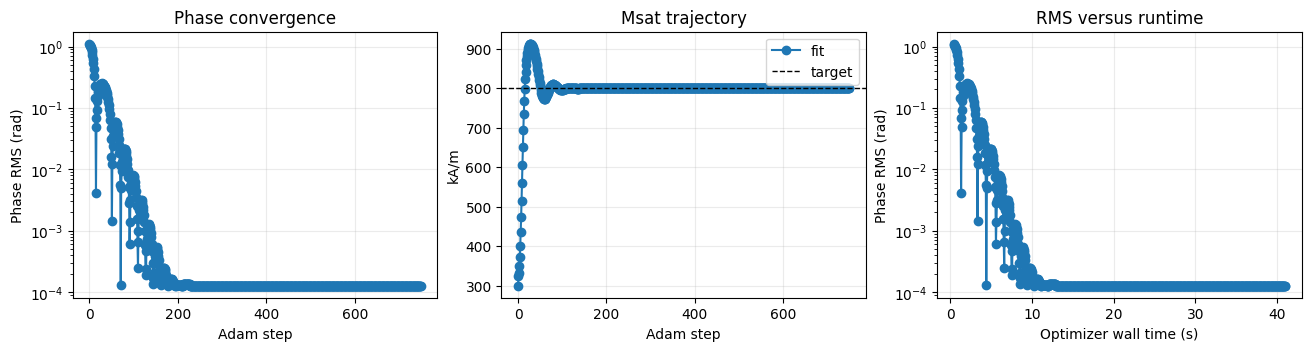

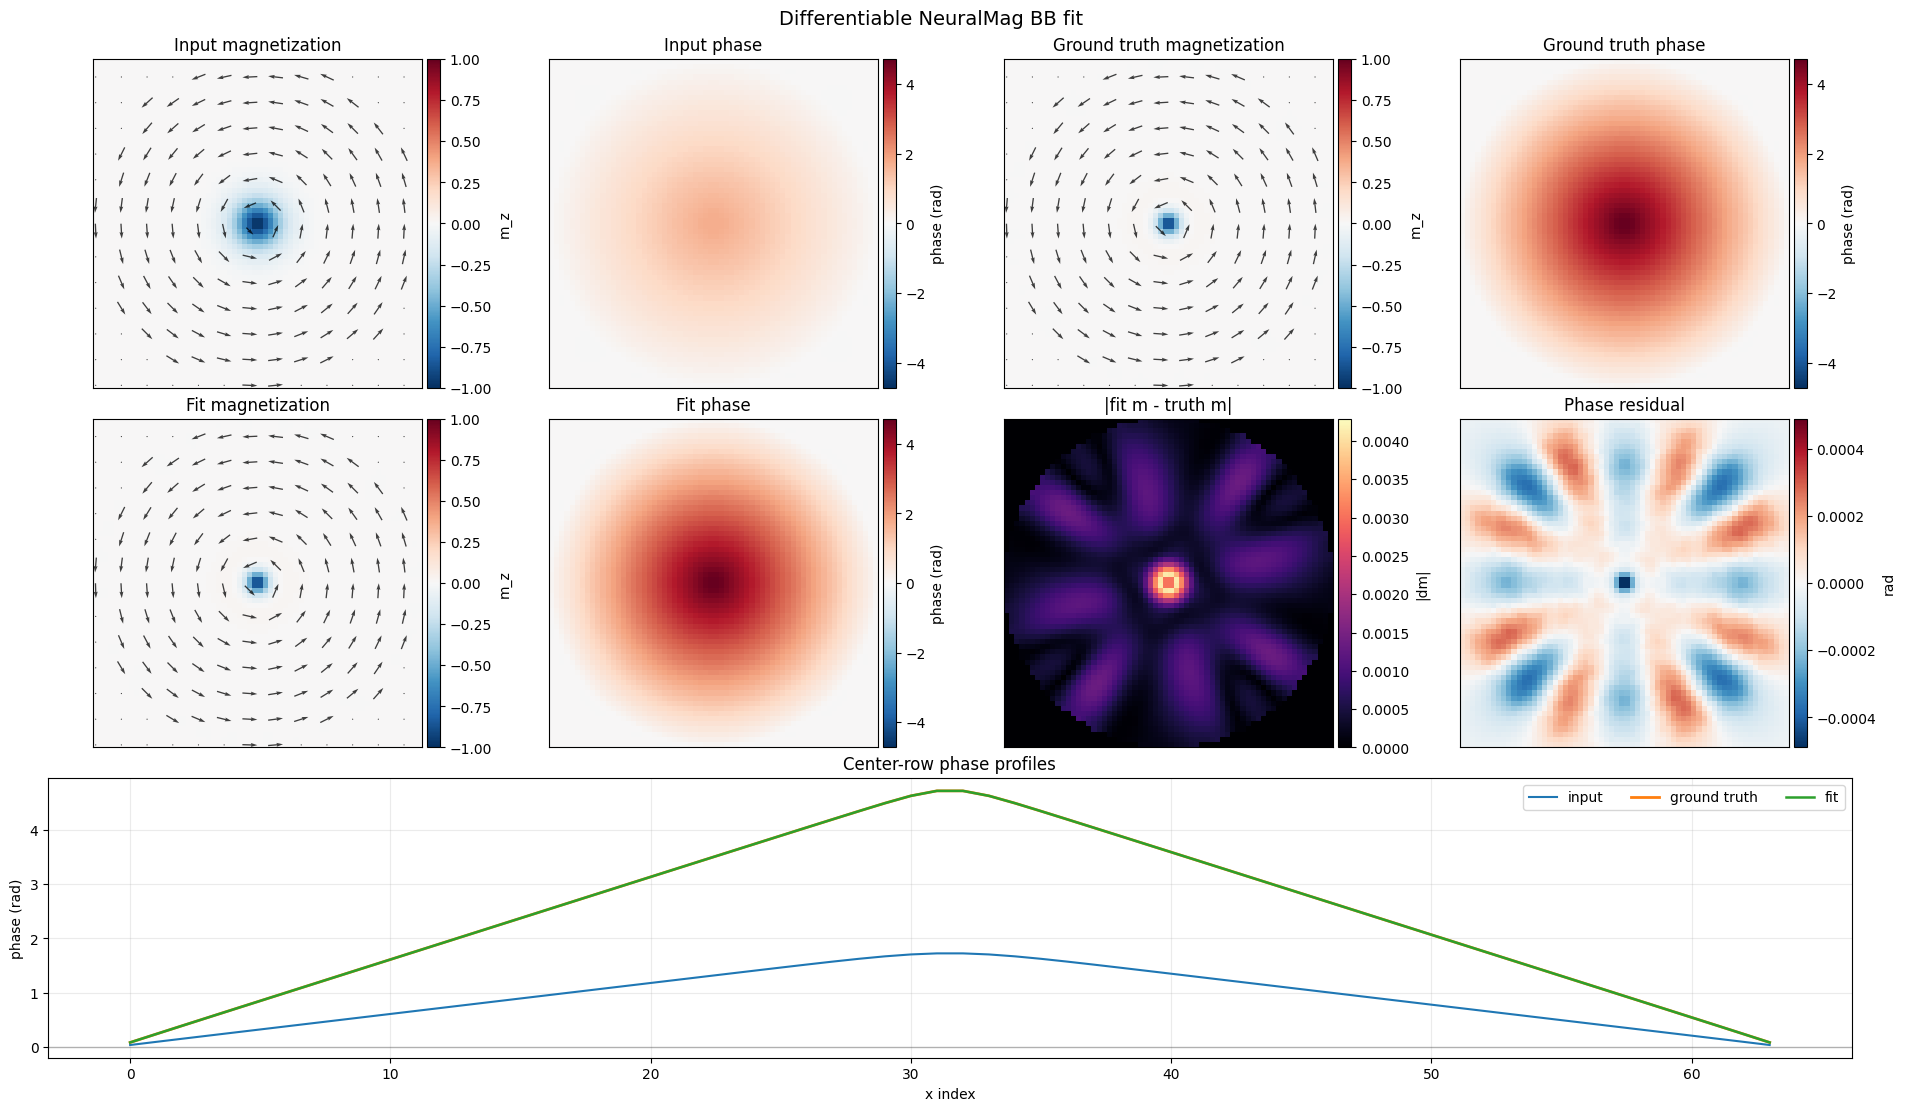

In [8]:
from mpl_toolkits.axes_grid1 import make_axes_locatable


def as_np(value):
    return np.asarray(jax.device_get(value), dtype=np.float64)


def add_colorbar(ax, im, label):
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="4%", pad=0.05)
    cb = plt.colorbar(im, cax=cax)
    cb.set_label(label)


def show_m_slice(ax, m_cell, title, *, quiver_step=5):
    mid = m_cell.shape[2] // 2
    im = ax.imshow(m_cell[:, :, mid, 2].T, cmap="RdBu_r", vmin=-1.0, vmax=1.0)
    x = np.arange(0, m_cell.shape[0], quiver_step)
    y = np.arange(0, m_cell.shape[1], quiver_step)
    xx, yy = np.meshgrid(x, y, indexing="xy")
    ax.quiver(
        xx,
        yy,
        m_cell[::quiver_step, ::quiver_step, mid, 0].T,
        m_cell[::quiver_step, ::quiver_step, mid, 1].T,
        color="k",
        pivot="mid",
        scale=22,
        width=0.004,
        alpha=0.75,
    )
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


def show_phase(ax, phase, title, limit):
    im = ax.imshow(phase, cmap="RdBu_r", vmin=-limit, vmax=limit)
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    return im


history = fit_result["history"]
fig, axs = plt.subplots(1, 3, figsize=(13, 3.4), constrained_layout=True)
steps = np.array([row["step"] for row in history])
rms = np.array([row["phase_rms"] for row in history])
msat = np.array([row["msat"] for row in history])
elapsed = np.array([row["elapsed_s"] for row in history])

axs[0].semilogy(steps, np.maximum(rms, 1e-30), marker="o")
axs[0].set_title("Phase convergence")
axs[0].set_xlabel("Adam step")
axs[0].set_ylabel("Phase RMS (rad)")
axs[0].grid(True, alpha=0.25)

axs[1].plot(steps, msat / 1e3, marker="o", label="fit")
axs[1].axhline(target_msat / 1e3, color="k", ls="--", lw=1.0, label="target")
axs[1].set_title("Msat trajectory")
axs[1].set_xlabel("Adam step")
axs[1].set_ylabel("kA/m")
axs[1].grid(True, alpha=0.25)
axs[1].legend()

axs[2].semilogy(np.maximum(elapsed, 1e-9), np.maximum(rms, 1e-30), marker="o")
axs[2].set_title("RMS versus runtime")
axs[2].set_xlabel("Optimizer wall time (s)")
axs[2].set_ylabel("Phase RMS (rad)")
axs[2].grid(True, alpha=0.25)
plt.show()

input_m_np = as_np(input_m_cell)
target_m_np = as_np(target_m_cell)
fit_m_np = as_np(fit_result["m_cell_final"])
input_phase_np = as_np(input_phase)
target_phase_np = as_np(target_phase)
fit_phase_np = as_np(fit_result["phase_pred"])
phase_resid_np = fit_phase_np - target_phase_np
m_error_np = np.linalg.norm(fit_m_np - target_m_np, axis=-1)

phase_lim = max(abs(float(arr.min())) for arr in (input_phase_np, target_phase_np, fit_phase_np))
phase_lim = max(phase_lim, max(abs(float(arr.max())) for arr in (input_phase_np, target_phase_np, fit_phase_np)), 1e-12)
resid_lim = max(abs(float(phase_resid_np.min())), abs(float(phase_resid_np.max())), 1e-12)
merr_lim = max(float(np.nanmax(m_error_np)), 1e-12)

fig = plt.figure(figsize=(18.5, 11.0), constrained_layout=True)
gs = fig.add_gridspec(3, 4, height_ratios=[1.0, 1.0, 0.85])
fig.suptitle("Differentiable NeuralMag BB fit", fontsize=14)

panels = [
    (0, 0, show_m_slice, input_m_np, "Input magnetization", "m_z", None),
    (0, 1, show_phase, input_phase_np, "Input phase", "phase (rad)", phase_lim),
    (0, 2, show_m_slice, target_m_np, "Ground truth magnetization", "m_z", None),
    (0, 3, show_phase, target_phase_np, "Ground truth phase", "phase (rad)", phase_lim),
    (1, 0, show_m_slice, fit_m_np, "Fit magnetization", "m_z", None),
    (1, 1, show_phase, fit_phase_np, "Fit phase", "phase (rad)", phase_lim),
]

for row, col, plot_fn, values, title, cbar_label, limit in panels:
    ax = fig.add_subplot(gs[row, col])
    im = plot_fn(ax, values, title) if limit is None else plot_fn(ax, values, title, limit)
    add_colorbar(ax, im, cbar_label)

ax = fig.add_subplot(gs[1, 2])
im = ax.imshow(m_error_np[:, :, m_error_np.shape[2] // 2].T, cmap="magma", vmin=0.0, vmax=merr_lim)
ax.set_title("|fit m - truth m|")
ax.set_xticks([])
ax.set_yticks([])
add_colorbar(ax, im, "|dm|")

ax = fig.add_subplot(gs[1, 3])
im = show_phase(ax, phase_resid_np, "Phase residual", resid_lim)
add_colorbar(ax, im, "rad")

ax = fig.add_subplot(gs[2, :])
x_index = np.arange(target_phase_np.shape[1])
row = target_phase_np.shape[0] // 2
ax.plot(x_index, input_phase_np[row], lw=1.5, label="input")
ax.plot(x_index, target_phase_np[row], lw=2.0, label="ground truth")
ax.plot(x_index, fit_phase_np[row], lw=1.8, label="fit")
ax.axhline(0.0, color="k", lw=1.0, alpha=0.25)
ax.set_title("Center-row phase profiles")
ax.set_xlabel("x index")
ax.set_ylabel("phase (rad)")
ax.grid(True, alpha=0.25)
ax.legend(ncol=3, loc="best")
plt.show()


2026-04-29 15:34:38 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-29 15:34:38 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-29 15:34:38 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)
2026-04-29 15:34:39 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-29 15:34:39 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-29 15:34:39 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-29 15:34:48 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-29 15:34:48 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-29 15:34:48 NeuralMag:INFO [TotalField] Register state methods (field: 'h', 

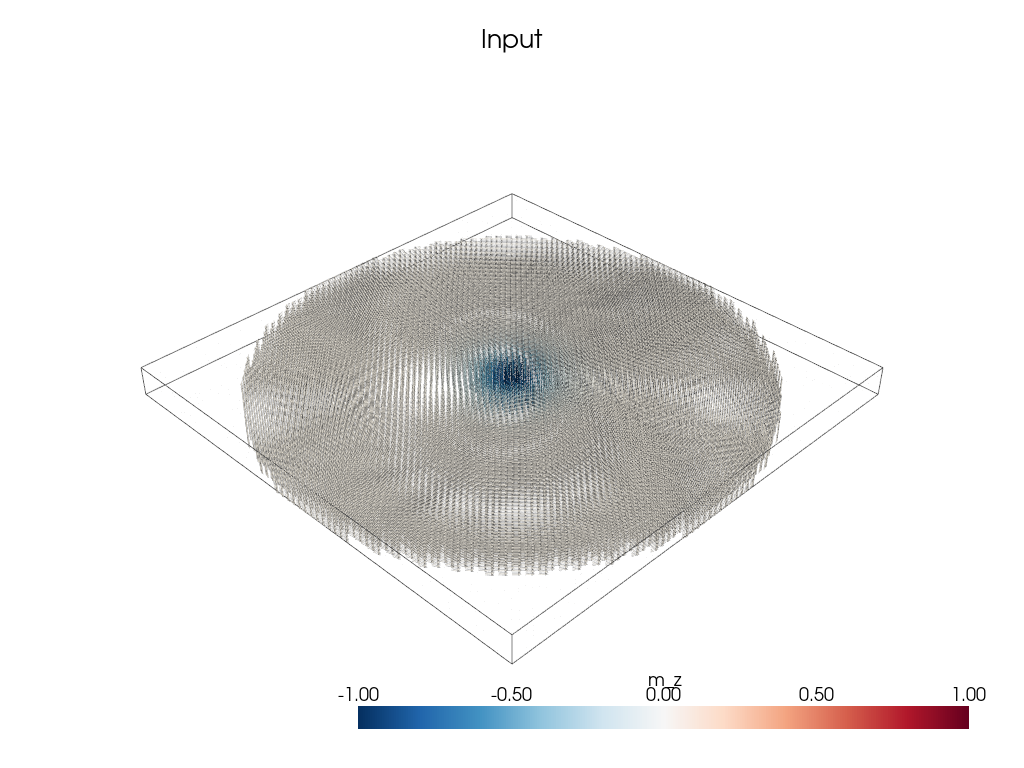

2026-04-29 15:34:48 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-29 15:34:48 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-29 15:34:48 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)


Wrote /Users/landers/LiberTEM-holo/notebooks/MBIR/vortex_3d_plots/vortex_input_bb_adam.vti


2026-04-29 15:34:49 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-29 15:34:49 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-29 15:34:49 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-29 15:34:57 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-29 15:34:57 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-29 15:34:57 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')


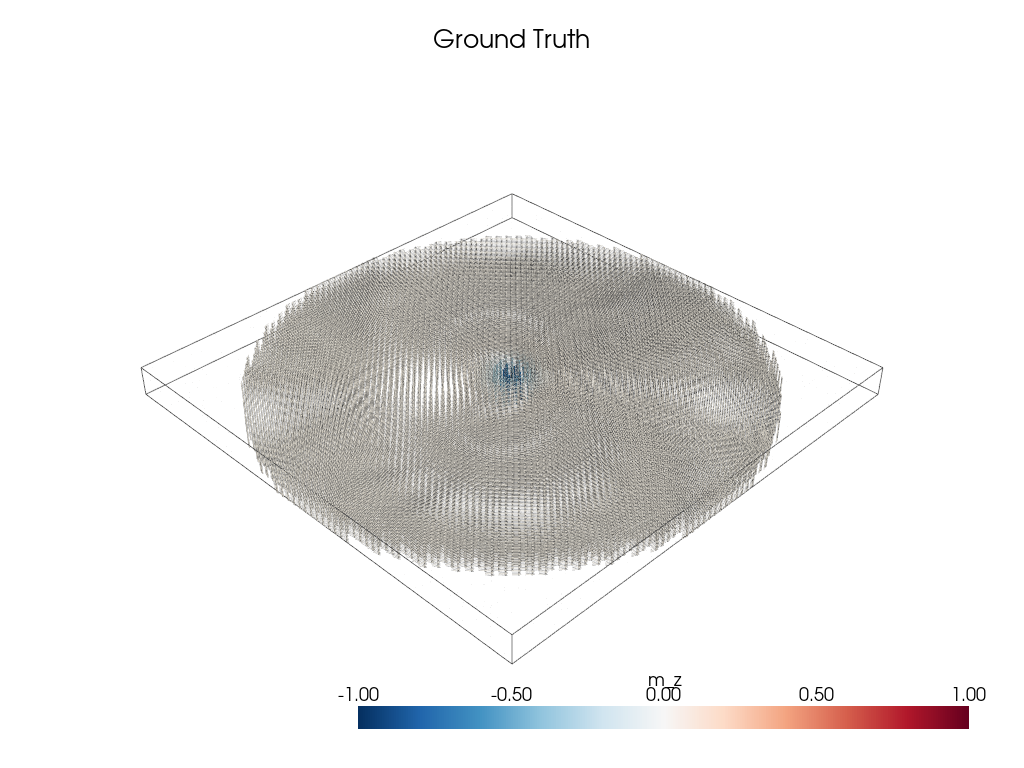

2026-04-29 15:34:58 NeuralMag:INFO [Mesh] 3D, 64 x 64 x 20 (size = 5e-09 x 5e-09 x 1e-09)
2026-04-29 15:34:58 NeuralMag:INFO [NeuralMag] Set default device to 'cuda:0'.
2026-04-29 15:34:58 NeuralMag:INFO [State] Running on device: cuda:0 (dtype = float64, backend = jax)


Wrote /Users/landers/LiberTEM-holo/notebooks/MBIR/vortex_3d_plots/vortex_ground_truth_bb_adam.vti


2026-04-29 15:34:59 NeuralMag:INFO [ExchangeField] Register state methods (field: 'h_exchange', energy: 'E_exchange', energy density: 'e_exchange')
2026-04-29 15:34:59 NeuralMag:INFO [DemagField] Register state methods (field: 'h_demag', energy: 'E_demag', energy density: 'e_demag')
2026-04-29 15:34:59 NeuralMag:INFO [DemagField]: Set up demag tensor
2026-04-29 15:35:07 NeuralMag:INFO [InterfaceDMIField] Register state methods (field: 'h_idmi', energy: 'E_idmi', energy density: 'e_idmi')
2026-04-29 15:35:07 NeuralMag:INFO [UniaxialAnisotropyField] Register state methods (field: 'h_uaniso', energy: 'E_uaniso', energy density: 'e_uaniso')
2026-04-29 15:35:07 NeuralMag:INFO [TotalField] Register state methods (field: 'h', energy: 'E', energy density: 'e')


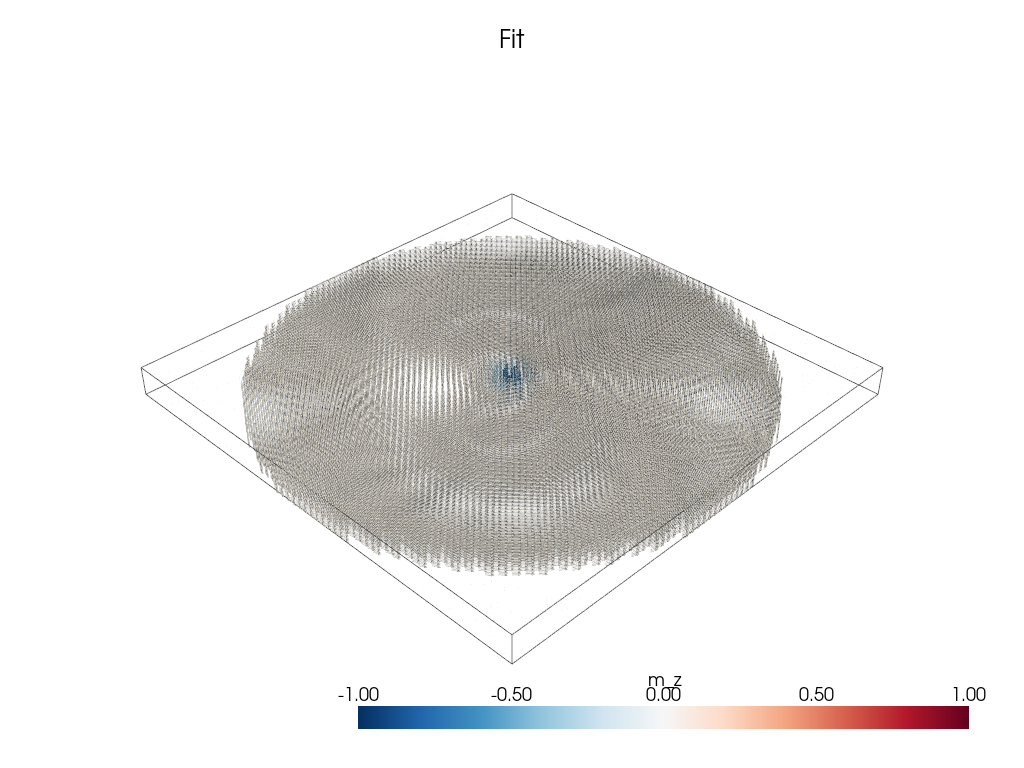

Wrote /Users/landers/LiberTEM-holo/notebooks/MBIR/vortex_3d_plots/vortex_fit_bb_adam.vti


In [9]:
# Optional 3D VTI export and PyVista view.
try:
    import pyvista as pv
except ImportError:
    pv = None

if pv is None:
    print("Install pyvista to use the 3D view cell.")
else:
    pv.set_jupyter_backend("static")
    output_dir = repo_root / "notebooks" / "MBIR" / "vortex_3d_plots"
    output_dir.mkdir(parents=True, exist_ok=True)

    def plot_vti_state(tag, m_cell_xyz, msat_a_per_m):
        state = build_vortex_state(rho_cell, np.asarray(m_cell_xyz, dtype=np.float32), msat_a_per_m)
        filename = output_dir / f"vortex_{tag}_bb_adam.vti"
        state.write_vti(["m"], str(filename))

        mesh = pv.read(str(filename))
        if "m" not in mesh.point_data:
            mesh = mesh.cell_data_to_point_data(pass_cell_data=True)
        mesh.point_data["m_z"] = np.asarray(mesh.point_data["m"])[:, 2]
        glyphs = mesh.glyph(orient="m", scale="m", factor=float(cellsize_nm_xyz[0]) * 1e-9)

        plotter = pv.Plotter()
        plotter.add_mesh(mesh.outline(), color="#555555", line_width=1.0)
        plotter.add_mesh(
            glyphs,
            scalars="m_z",
            cmap="RdBu_r",
            clim=[-1.0, 1.0],
            lighting=True,
            smooth_shading=True,
            scalar_bar_args={"title": "m_z", "fmt": "%.2f"},
        )
        plotter.add_title(tag.replace("_", " ").title(), font_size=10)
        plotter.show()
        print(f"Wrote {filename}")

    for tag, m_cell in {
        "input": input_m_np,
        "ground_truth": target_m_np,
        "fit": fit_m_np,
    }.items():
        plot_vti_state(tag, m_cell, target_msat)
